# Endometrium — Analiz Defteri

Bu defter, makalede raporlanan ön-tanımlı birincil analizi, kalibrasyon, karar eğrisi
ve SHAP analizlerini ve duyarlılık analizlerini üretir.

> Akaydın Gültürk, E.; Genç, Ş.Ö. Hematological Versus Clinical Predictors of Tumor
> Grade in Endometrial Cancer: A Comparative Machine Learning Study with SHAP-Based
> Explainability. *Diagnostics* **2026**.

## Üç tasarım kararı

1. **ER ve PR hiçbir modelde yer almaz.** İki bağımsız gerekçe: (a) bu belirteçler
   preoperatif biyopside çalışılmaz, değerler histerektomi materyalinden gelir, yani
   tahminin yapılacağı anda mevcut değildir; (b) SPSS değer etiketleri 1='10-20' …
   9='90-100', 10='only positive' şeklindedir ve **negatif kategorisi yoktur** — `0`
   kodu "negatif" değil **"bakılmamış"** demektir. Değişken modele konulduğunda bir
   eksiklik göstergesi olarak öğrenilir. Preoperatif klinik set bu nedenle
   `age + CA-125 + preoperatif albümin`'dir. Bölüm 12 bunu belgeler.

2. **Üç katmanlı kohort yapısı.** Her analiz üç kohortta çalışır: (i) tüm kohort
   n=225; (ii) yalnızca endometrioid n=183; (iii) reseptör durumu gerçekten bilinen
   n=159. Gerekçe: G3 olaylarının %66'sı non-endometrioiddir ve non-endometrioid
   tümörlerin %93'ü G3'tür; yani "G3 vs G1–G2" görevi büyük ölçüde histolojik alt tip
   görevidir. Kohort homojenleştikçe sinyalin gerçekte ne olduğu görünür hale gelir.

3. **Youden eşiği her eğitim fold'u içinde seçilir**, havuzlanmış tahminlerden değil.
   Havuzlanmış tahminlerden eşik seçmek test verisini kullanmak anlamına gelir.

## Çalıştırma

Google Colab'da çalıştırılmak üzere yazılmıştır. Varsayılan ayarlar (`QUICK = False`,
`N_REPEATS = 20`, `N_BOOT = 5000`, `N_PERM = 200`) makalede raporlanan değerlerdir.
Bölüm 0 ortamın çekirdek sayısını yazdırır; ücretsiz Colab'da (2 çekirdek) tahmini
süre 60–90 dakikadır. `QUICK = True` hızlı bir deneme çalıştırması yapar ve
**makaledeki sayıları üretmez**.

Veri dosyası depoda yoktur; üst dizindeki README'nin "Data availability" bölümüne
bakınız.


## 0. Kurulum


In [ ]:
!pip -q install pyreadstat statsmodels scikit-learn shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 62.1 MB/s eta 0:00:00


In [ ]:

import warnings, json, os, itertools
import numpy as np, pandas as pd, pyreadstat
from scipy import stats
from scipy.stats import norm
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, brier_score_loss,
                             average_precision_score, balanced_accuracy_score,
                             matthews_corrcoef)
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":300,"font.size":10})

QUICK      = False        # True -> hizli deneme
REFIT_RULE = "best"       # "best" | "1se"  (1-SE bu n'de patolojik, bkz. bolum 5b)
SEED       = 42
# Colab ucretsiz surumde 2 cekirdek var; asagidaki degerler ona gore secildi.
# Kaynak bilgisi ciktisinda cekirdek >= 4 ise sunlari yukseltebilirsiniz:
#   N_REPEATS 20, N_BOOT 5000, N_PERM 200  (sonuclar ucuncu ondalikta degisir)
N_REPEATS  = 3   if QUICK else 20
N_BOOT     = 500 if QUICK else 5000
N_PERM     = 20  if QUICK else 200
ALPHA      = 0.05
DELTA_AUC  = 0.70         # non-superiority marji (post hoc, exploratory)
DELTA_INC  = 0.05         # inkremental deger marji
DCA_LO, DCA_HI = 0.05, 0.40
print("QUICK=%s REFIT_RULE=%s N_REPEATS=%d N_BOOT=%d N_PERM=%d"
      % (QUICK, REFIT_RULE, N_REPEATS, N_BOOT, N_PERM))

# ---- CALISMA ORTAMI KONTROLU ----
# Colab Pro olup olmadiginizi bilmenize gerek yok; asagidaki cikti karari veriyor.
import multiprocessing, shutil
_cores = multiprocessing.cpu_count()
try:
    _ram = round(int(open("/proc/meminfo").readline().split()[1])/1024/1024, 1)
except Exception:
    _ram = float("nan")
print()
print("ORTAM: %d cekirdek, %.1f GB RAM" % (_cores, _ram))
if _cores <= 2:
    print("  -> Ucretsiz Colab. Mevcut ayarlarla tahmini sure ~60-90 dk. Boyle birakin.")
elif _cores <= 4:
    print("  -> Orta seviye. Isterseniz N_REPEATS=20, N_BOOT=5000, N_PERM=200 yapabilirsiniz.")
else:
    print("  -> Guclu ortam. N_REPEATS=20, N_BOOT=5000, N_PERM=200 yapin; sure yine makul kalir.")
print("  Not: sekmeyi acik tutun. Colab oturumu uzun bosluklarda kopabilir.")


QUICK=False REFIT_RULE=best N_REPEATS=20 N_BOOT=5000 N_PERM=200

ORTAM: 8 cekirdek, 51.0 GB RAM
  -> Guclu ortam. N_REPEATS=20, N_BOOT=5000, N_PERM=200 yapin; sure yine makul kalir.
  Not: sekmeyi acik tutun. Colab oturumu uzun bosluklarda kopabilir.


## 1. Veri yükleme

`MODE` satırını düzenleyin. Gereken dosya klinik değişkenleri içeren ana `.sav`
(226 satır, 41 kolon). `endometrium ca 226 hasta new.sav` **kullanılamaz**.


In [ ]:

MODE = "A"   # "A"=Colab dosya secici | "B"=Google Drive | "C"=yerel yol
SAV_PATH = None

if MODE == "A":
    from google.colab import files
    up = files.upload(); SAV_PATH = list(up.keys())[0]
elif MODE == "B":
    from google.colab import drive; drive.mount("/content/drive", force_remount=False)
    SAV_PATH = "/content/drive/MyDrive/endometrium ca 226 hasta (1) (2).sav"   # <-- duzeltin
else:
    SAV_PATH = "endometrium ca 226 hasta (1) (2).sav"                          # <-- duzeltin

assert SAV_PATH and os.path.exists(SAV_PATH), "Dosya bulunamadi: %s" % SAV_PATH
_c,_m = pyreadstat.read_sav(SAV_PATH)
print("Dosya :", SAV_PATH, "| boyut:", _c.shape, "(beklenen (226, 41))")
REQ = ["GRADE","type","Dage","ca125","albumin","östrojen","progesteron",
       "eozinofil","lenfosit","monosit","nötrofil","wbc","platelet",
       "nlr","plr","pıv","sıı","sırı","mlr","dnlr","elr"]
_miss=[c for c in REQ if c not in _c.columns]
if _miss: raise SystemExit("YANLIS DOSYA — eksik kolonlar: %s" % _miss)
print("Kolonlar: gerekli 21 kolonun tamami mevcut  OK")
if "name" in _c.columns:
    print("UYARI: 'name' kolonunda hasta adlari var — paylasilacak surumden SILIN.")
del _c,_m


Saving endometrium ca 226 hasta (1) (2) (1).sav to endometrium ca 226 hasta (1) (2) (1).sav
Dosya : endometrium ca 226 hasta (1) (2) (1).sav | boyut: (226, 41) (beklenen (226, 41))
Kolonlar: gerekli 21 kolonun tamami mevcut  OK
UYARI: 'name' kolonunda hasta adlari var — paylasilacak surumden SILIN.


### 1.1 Türetme ve öznitelik setleri

**Kritik değişiklik.** ER ve PR hiçbir öznitelik setinde yok. Değer etiketleri
1='10-20' … 9='90-100', 10='only positive' — **negatif kategorisi yok**. `0` kodu
"bakılmamış" demektir ve modele konulduğunda bir eksiklik göstergesi olarak öğrenilir.
Bölüm 12 bunu belgeler ve Tablo 1 için doğru sayıları üretir.


In [ ]:

def load_data(path=None):
    path = SAV_PATH if path is None else path
    df,_ = pyreadstat.read_sav(path)
    n_id = len(df)
    df = df.dropna(subset=["GRADE"]).copy()
    df["y"] = (df["GRADE"] == 3).astype(int)

    dsum = df[["nötrofil","lenfosit","monosit","eozinofil"]].sum(axis=1)
    bad = (df["wbc"]-dsum).abs() > 2
    df.loc[bad,"wbc"] = dsum[bad]          # NOT: bu onarim VIF hesabindan ONCE uygulanir

    df["LMR"] = df["lenfosit"]/df["monosit"]
    df["PNI"] = 10*df["albumin"] + 5*df["lenfosit"]     # 5*L(10^3/uL) == 0.005*L(/uL)
    # ER/PR: deger etiketleri 1='10-20' ... 9='90-100', 10='only positive'.
    # NEGATIF KATEGORISI YOK. Yazar teyidi: 0 kodu "bakilmamis" demek, "negatif" DEGIL;
    # bakilan her hastada ER pozitif. Dolayisiyla 0 bir EKSIKLIK GOSTERGESIDIR.
    # Hicbir modelde kullanilmaz; yalnizca bolum 12'de belgelenir.
    df["ER_assessed"] = np.where(df["östrojen"].isna(),    np.nan, (df["östrojen"]>0).astype(float))
    df["PR_assessed"] = np.where(df["progesteron"].isna(), np.nan, (df["progesteron"]>0).astype(float))
    df["endometrioid"] = (df["type"]==1)
    df = df.rename(columns={"nlr":"NLR","plr":"PLR","pıv":"PIV","sıı":"SII","sırı":"SIRI",
        "mlr":"MLR","dnlr":"dNLR","elr":"ELR","elp":"ELP","nötrofil":"neu","lenfosit":"lym",
        "monosit":"mon","eozinofil":"eos","platelet":"plt","wbc":"WBC","Dage":"age",
        "ca125":"CA125","albumin":"albumin_preop"})
    df.attrs["n_identified"]=n_id; df.attrs["n_wbc_fixed"]=int(bad.sum())
    return df

df = load_data(); y = df["y"].values
ENDO = df["endometrioid"].values
ER_ASSESSED = (df["östrojen"] > 0).values     # reseptor durumu gercekten bilinen hastalar
print("tanimlanan %d -> grade bilinen %d | G3 %d (%.1f%%) | WBC onarilan %d"
      % (df.attrs["n_identified"], len(y), y.sum(), 100*y.mean(), df.attrs["n_wbc_fixed"]))

FULL = ["eos","lym","mon","neu","WBC","plt","NLR","PLR","PIV","SII","SIRI","MLR","dNLR","ELR"]
SET = {
 "Set A":      ["neu","lym","mon","plt","NLR","LMR","PIV","ELR"],   # inflamatuar, indirgenmis
 "Set A-full": FULL,                                                # inflamatuar, tam panel
 "Set B":      ["age","CA125","albumin_preop"],                     # PREOPERATIF klinik
}
SET["Set C"] = SET["Set A"] + SET["Set B"]                           # birlesik
SET_SECONDARY = {}   # ER/PR hicbir modele girmez — bkz. bolum 12

# ---- UC KATMANLI KOHORT YAPISI ----
# Kohort homojenlestikce sinyalin ne oldugunu gormek icin.
COHORTS = {
 "Full cohort":       np.ones(len(df), bool),   # n=225
 "Endometrioid only": ENDO,                     # n=183, G3 %10.9
 "ER assessed":       ER_ASSESSED,              # n=159, reseptor bilinen; ER varyansi 0
}
def mask_of(cols, cohort="Full cohort"):
    return COHORTS[cohort] & df[cols].notna().all(axis=1).values

for cn,cm in COHORTS.items():
    print("KOHORT %-18s n=%3d | G3 %2d (%.1f%%) | endometrioid %.1f%%"
          % (cn, cm.sum(), int(y[cm].sum()), 100*y[cm].mean(), 100*ENDO[cm].mean()))

print("\nOZNITELIK SETLERI  (ER ve PR HICBIR SETTE YOK)")
for s,c in SET.items():
    for cn in COHORTS:
        m=mask_of(c,cn); ev=int(y[m].sum())
        print("  %-11s %-18s n=%3d olay=%2d p=%2d EPV=%4.1f" % (s,cn,m.sum(),ev,len(c),ev/len(c)))


tanimlanan 226 -> grade bilinen 225 | G3 59 (26.2%) | WBC onarilan 5
KOHORT Full cohort        n=225 | G3 59 (26.2%) | endometrioid 81.3%
KOHORT Endometrioid only  n=183 | G3 20 (10.9%) | endometrioid 100.0%
KOHORT ER assessed        n=159 | G3 28 (17.6%) | endometrioid 87.4%

OZNITELIK SETLERI  (ER ve PR HICBIR SETTE YOK)
  Set A       Full cohort        n=224 olay=59 p= 8 EPV= 7.4
  Set A       Endometrioid only  n=182 olay=20 p= 8 EPV= 2.5
  Set A       ER assessed        n=159 olay=28 p= 8 EPV= 3.5
  Set A-full  Full cohort        n=224 olay=59 p=14 EPV= 4.2
  Set A-full  Endometrioid only  n=182 olay=20 p=14 EPV= 1.4
  Set A-full  ER assessed        n=159 olay=28 p=14 EPV= 2.0
  Set B       Full cohort        n=181 olay=48 p= 3 EPV=16.0
  Set B       Endometrioid only  n=147 olay=17 p= 3 EPV= 5.7
  Set B       ER assessed        n=132 olay=24 p= 3 EPV= 8.0
  Set C       Full cohort        n=181 olay=48 p=11 EPV= 4.4
  Set C       Endometrioid only  n=147 olay=17 p=11 EPV= 1.5
  Se

## 2. Akış diyagramı, eksiklik, dahil vs dışlanan

Dahil-vs-dışlanan karşılaştırması seçim yanlılığını değerlendirmek içindir.


In [ ]:

raw,_ = pyreadstat.read_sav(SAV_PATH)
cbc = ["eos","lym","mon","neu","WBC","plt"]
print("=== FLOW ===")
print("Identified                                  : %d" % len(raw))
print("Excluded: grade not reported                : %d" % int(raw["GRADE"].isna().sum()))
print("Analytic cohort                             : %d (G1 %d, G2 %d, G3 %d)"
      % (len(df),(df.GRADE==1).sum(),(df.GRADE==2).sum(),(df.GRADE==3).sum()))
inc = df[cbc].isna().any(axis=1)
print("Excluded: incomplete differential count     : %d (grade %s)" % (inc.sum(), df.loc[inc,"GRADE"].tolist()))
print("Set A / Set A-full                          : n=%d (%d events)" % (mask_of(SET["Set A"]).sum(), y[mask_of(SET["Set A"])].sum()))
print("Set B / Set C (preoperative clinical)       : n=%d (%d events)" % (mask_of(SET["Set C"]).sum(), y[mask_of(SET["Set C"])].sum()))

rows=[]
for c,lab in [("age","Age"),("CA125","CA-125"),("albumin_preop","Preoperative albumin"),
              ("ER_assessed","ER assessed (0 code = not assessed)"),("PR_assessed","PR assessed")]+[(c,c) for c in cbc]:
    k=int(df[c].isna().sum()); rows.append(dict(variable=lab,missing=k,pct=round(100*k/len(df),1)))
miss=pd.DataFrame(rows); print("\n=== TABLE S2  missingness (n=%d) ===" % len(df)); print(miss.to_string(index=False))
miss.to_csv("tableS2_missingness.csv",index=False)

pat=(df.assign(alb=df.albumin_preop.isna(), ca=df.CA125.isna(), erpr=df.ER_assessed.isna())
       .groupby(["alb","ca","erpr"]).size().rename("n").reset_index())
print("\n=== joint missingness pattern ==="); print(pat.to_string(index=False))
pat.to_csv("tableS2b_missing_pattern.csv",index=False)

# --- dahil vs dislanan (Set B maskesine gore) ---
inB = mask_of(SET["Set B"])
comp=[]
for v,lab in [("age","Age"),("CA125","CA-125"),("NLR","NLR"),("ELR","ELR"),
              ("PIV","PIV"),("lym","Lymphocytes"),("plt","Platelets")]:
    a=df.loc[inB,v].dropna(); b=df.loc[~inB,v].dropna()
    p=stats.mannwhitneyu(a,b).pvalue if len(a)>2 and len(b)>2 else np.nan
    comp.append(dict(variable=lab, included_median=round(a.median(),3), excluded_median=round(b.median(),3),
                     n_incl=len(a), n_excl=len(b), p_MWU=round(p,3)))
g3=pd.crosstab(inB, y)
comp.append(dict(variable="G3 proportion", included_median=round(y[inB].mean(),3),
                 excluded_median=round(y[~inB].mean(),3), n_incl=int(inB.sum()), n_excl=int((~inB).sum()),
                 p_MWU=round(stats.chi2_contingency(g3)[1],3)))
endo_ct=pd.crosstab(inB, ENDO)
comp.append(dict(variable="Endometrioid proportion", included_median=round(ENDO[inB].mean(),3),
                 excluded_median=round(ENDO[~inB].mean(),3), n_incl=int(inB.sum()), n_excl=int((~inB).sum()),
                 p_MWU=round(stats.chi2_contingency(endo_ct)[1],3)))
cmp_df=pd.DataFrame(comp)
print("\n=== TABLE S2c  included vs excluded (Set B complete-case) ==="); print(cmp_df.to_string(index=False))
cmp_df.to_csv("tableS2c_included_vs_excluded.csv",index=False)


=== FLOW ===
Identified                                  : 226
Excluded: grade not reported                : 1
Analytic cohort                             : 225 (G1 133, G2 33, G3 59)
Excluded: incomplete differential count     : 1 (grade [1.0])
Set A / Set A-full                          : n=224 (59 events)
Set B / Set C (preoperative clinical)       : n=181 (48 events)

=== TABLE S2  missingness (n=225) ===
                           variable  missing  pct
                                Age        0  0.0
                             CA-125        5  2.2
               Preoperative albumin       44 19.6
ER assessed (0 code = not assessed)       29 12.9
                        PR assessed       29 12.9
                                eos        1  0.4
                                lym        1  0.4
                                mon        1  0.4
                                neu        1  0.4
                                WBC        1  0.4
                                plt  

## 3. Histolojik alt tip × derece

Bu bölüm makalenin yeniden çerçevelenmesinin dayanağıdır: alt tipi modelden çıkarmak
karıştırıcılığı ortadan kaldırmıyor, çünkü yaş ve ER negatifliği alt tipin vekilleri.


In [ ]:

lab_map = {1:"Endometrioid",2:"Serous",3:"Mucinous",4:"Clear cell",5:"Mixed",
           6:"Squamous",7:"Transitional",8:"Small cell",9:"Undifferentiated"}
df["subtype"]=df["type"].map(lab_map)
ct=pd.crosstab(df.subtype, df.GRADE.map({1:"G1",2:"G2",3:"G3"}), margins=True)
ct["G3 %"]=(100*ct.get("G3",0)/ct["All"]).round(1)
print("=== TABLE S5  histologic subtype by grade ==="); print(ct.to_string())
ct.to_csv("tableS5_subtype_by_grade.csv")

print("\nEndometrioid       n=%d, G3 %d (%.1f%%)" % (ENDO.sum(), y[ENDO].sum(), 100*y[ENDO].mean()))
print("Non-endometrioid   n=%d, G3 %d (%.1f%%)" % ((~ENDO).sum(), y[~ENDO].sum(), 100*y[~ENDO].mean()))
print("G3 events that are non-endometrioid: %d / %d (%.1f%%)"
      % (((y==1)&(~ENDO)).sum(), y.sum(), 100*((y==1)&(~ENDO)).sum()/y.sum()))
print("\nAge  : endometrioid %.1f vs non-endometrioid %.1f"
      % (df.loc[ENDO,"age"].mean(), df.loc[~ENDO,"age"].mean()))
print("ER NOT ASSESSED: endometrioid %.1f%% vs non-endometrioid %.1f%%"
      % (100*(1-df.loc[ENDO,"ER_assessed"].mean()), 100*(1-df.loc[~ENDO,"ER_assessed"].mean())))
print("\nYORUM: yas ve ER negatifligi alt tipin vekilleri. Bu yuzden butun modeller")
print("       asagida hem tum kohortta hem endometrioid-only kohortta calistirilir.")


=== TABLE S5  histologic subtype by grade ===
GRADE              G1  G2  G3  All   G3 %
subtype                                  
Clear cell          1   0   5    6   83.3
Endometrioid      130  33  20  183   10.9
Mixed               0   0  10   10  100.0
Mucinous            1   0   0    1    0.0
Serous              0   0  21   21  100.0
Squamous            1   0   1    2   50.0
Undifferentiated    0   0   2    2  100.0
All               133  33  59  225   26.2

Endometrioid       n=183, G3 20 (10.9%)
Non-endometrioid   n=42, G3 39 (92.9%)
G3 events that are non-endometrioid: 39 / 59 (66.1%)

Age  : endometrioid 57.6 vs non-endometrioid 67.4
ER NOT ASSESSED: endometrioid 12.0% vs non-endometrioid 47.4%

YORUM: yas ve ER negatifligi alt tipin vekilleri. Bu yuzden butun modeller
       asagida hem tum kohortta hem endometrioid-only kohortta calistirilir.


## 4. Fold içi kolinearite elemesi

VIF sonuçtan bağımsızdır (yalnızca X kullanır), dolayısıyla global uygulama denetimli
seçimdeki gibi sızıntı yaratmaz (Hastie, Tibshirani & Friedman, ESL 2. baskı §7.10.2).
Yine de eleme her dış eğitim fold'unda bağımsız tekrarlanır.


In [ ]:

def vif_series(X):
    Z=((X-X.mean())/X.std()).dropna()
    Zc=np.column_stack([np.ones(len(Z)),Z.values])
    return pd.Series([variance_inflation_factor(Zc,i+1) for i in range(Z.shape[1])],index=Z.columns)

def greedy_reduce(X, protect=("NLR",), thresh=10.0):
    cols=[c for c in X.columns if c not in ("MLR","dNLR","WBC","eos")]
    if "LMR" in X.columns and "LMR" not in cols: cols.append("LMR")
    while len(cols)>2:
        v=vif_series(X[cols])
        if v.max()<=thresh: break
        cand=v.drop(labels=[p for p in protect if p in v.index], errors="ignore")
        if cand.empty or cand.max()<=thresh: break
        cols.remove(cand.idxmax())
    return cols

v=vif_series(df[FULL])
Z=((df[FULL]-df[FULL].mean())/df[FULL].std()).dropna()
print("14-variable panel : max VIF %.1f | condition number %.1f"
      % (v.max(), np.linalg.cond(Z.values)))
print("Set A             : max VIF %.2f" % vif_series(df[SET["Set A"]]).max())
print("NOT: WBC onarimi VIF hesabindan ONCE uygulandi.")

Xg=df[FULL+["LMR"]]; m=mask_of(SET["Set A-full"]); Xg,yg=Xg[m],y[m]
cnt={}; folds=0
for rep in range(5):
    for tr,_ in StratifiedKFold(5,shuffle=True,random_state=SEED+rep).split(Xg,yg):
        sel=greedy_reduce(Xg.iloc[tr]); folds+=1
        for c in sel: cnt[c]=cnt.get(c,0)+1
tabS4=(pd.Series(cnt).div(folds).sort_values(ascending=False).rename("retention_rate")
         .reset_index().rename(columns={"index":"variable"}))
tabS4["in_paper_SetA"]=tabS4.variable.isin(SET["Set A"])
print("\n=== TABLE S4  fold-wise reduction (%d folds) ===" % folds); print(tabS4.to_string(index=False))
tabS4.to_csv("tableS4_foldwise_vif.csv",index=False)


14-variable panel : max VIF 591.7 (paper 660.4) | kappa 94.9 (paper 110.3)
Set A             : max VIF 8.36 (paper 8.36)
NOT: WBC onarimi VIF'ten ONCE uygulandi; makalede sira belirtilmemis, revizyonda yazilmali.

=== TABLE S4  fold-wise reduction (25 folds) ===
variable  retention_rate  in_paper_SetA
     lym            1.00           True
     mon            1.00           True
     neu            1.00           True
     plt            1.00           True
     NLR            1.00           True
     ELR            1.00           True
     LMR            1.00           True
     PIV            0.64           True


## 5. Birincil model — elastic-net, fold içi Youden eşiği

İki düzeltme: (a) algoritma seçimi yok, tek ön-tanımlı model; (b) sınıflandırma eşiği
**her eğitim fold'unda** belirlenip ilgili dış test fold'una uygulanıyor — havuzlanmış
tahminlerden seçilmiyor.

Her set üç kohortta da çalıştırılıyor. Beklenen örüntü (ön testlerden):

| Kohort | Set A | Set B |
|---|---|---|
| Tüm kohort (n=224/181) | 0.534 | 0.680 |
| Endometrioid-only (n=182/147) | 0.601 | 0.374 |
| ER bakılmış (n=159/132) | 0.621 (GA 0.494–0.742) | 0.635 (GA 0.491–0.772) |

Homojen kohortlarda üç setin de güven aralığı 0.50'yi içeriyor. Bu, tüm kohorttaki
0.680'in histoloji bileşiminden geldiğinin en temiz kanıtı.


In [ ]:

def one_se_refit(ckey):
    def _r(cv):
        means=np.asarray(cv["mean_test_score"])
        ns=sum(1 for k in cv if k.startswith("split") and k.endswith("_test_score"))
        ses=np.asarray(cv["std_test_score"])/np.sqrt(max(ns,1))
        b=np.nanargmax(means); ok=np.flatnonzero(means>=means[b]-ses[b])
        return int(ok[np.nanargmin(ckey(cv)[ok])])
    return _r
def enet_complexity(cv):
    Cv=np.array([p["clf__C"] for p in cv["params"]],float)
    l1=np.array([p["clf__l1_ratio"] for p in cv["params"]],float)
    return np.log10(Cv)-0.1*l1
def estimator(seed=SEED):
    return Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler()),
        ("clf",LogisticRegression(penalty="elasticnet",solver="saga",max_iter=20000,
                                  class_weight="balanced",random_state=seed))])
GRID={"clf__C":np.logspace(-5,1,20),"clf__l1_ratio":[0.0,0.5,1.0]}
def _refit(rule): return one_se_refit(enet_complexity) if rule=="1se" else True

def nested_cv(X, yv, n_repeats=N_REPEATS, rule=None, seed=SEED):
    """Doner: ortalanmis oof olasilik, fold-ici esikle sinif tahmini, secilen C'ler."""
    rule = REFIT_RULE if rule is None else rule
    psum=np.zeros(len(yv)); votes=np.zeros(len(yv)); picks=[]
    for rep in range(n_repeats):
        for tr,te in StratifiedKFold(5,shuffle=True,random_state=seed+rep).split(X,yv):
            g=GridSearchCV(clone(estimator()),GRID,scoring="roc_auc",
                           cv=StratifiedKFold(5,shuffle=True,random_state=seed+rep),
                           refit=_refit(rule),n_jobs=-1,error_score=0.5)
            g.fit(X[tr],yv[tr]); picks.append(g.best_params_)
            ptr=g.best_estimator_.predict_proba(X[tr])[:,1]
            fpr,tpr,thr=roc_curve(yv[tr],ptr); t_in=thr[np.argmax(tpr-fpr)]   # ESIK EGITIM FOLD'UNDA
            pte=g.best_estimator_.predict_proba(X[te])[:,1]
            psum[te]+=pte; votes[te]+=(pte>=t_in)
    return psum/n_repeats, (votes/n_repeats>=0.5).astype(int), picks

def boot_auc_ci(yv,p,n=N_BOOT,seed=SEED):
    r=np.random.default_rng(seed); ip=np.flatnonzero(yv==1); ineg=np.flatnonzero(yv==0)
    b=[roc_auc_score(yv[i],p[i]) for i in
       (np.concatenate([r.choice(ip,ip.size,True),r.choice(ineg,ineg.size,True)]) for _ in range(n))]
    return np.percentile(b,2.5), np.percentile(b,97.5)

def summarize(yv,p,pred):
    tn=((pred==0)&(yv==0)).sum(); tp=((pred==1)&(yv==1)).sum()
    fp=((pred==1)&(yv==0)).sum(); fn=((pred==0)&(yv==1)).sum()
    pr=yv.mean()
    return dict(auc=roc_auc_score(yv,p), aucpr=average_precision_score(yv,p),
                bal_acc=balanced_accuracy_score(yv,pred), mcc=matthews_corrcoef(yv,pred),
                sens=100*tp/max(tp+fn,1), spec=100*tn/max(tn+fp,1),
                brier=brier_score_loss(yv,p), brier_prevalence_only=pr*(1-pr))

OOF={}; rows=[]
for cohort in COHORTS:
    for s,cols in SET.items():
        m=mask_of(cols,cohort); yv=y[m]
        if yv.sum()<8: print("%-19s %-11s atlandi (olay<8)"%(cohort,s)); continue
        p,pred,picks=nested_cv(df.loc[m,cols].values, yv)
        lo,hi=boot_auc_ci(yv,p); mt=summarize(yv,p,pred)
        OOF[(cohort,s)]=(m,p,pred,yv)
        Cs=[q["clf__C"] for q in picks]
        rows.append(dict(cohort=cohort,feature_set=s,n=int(m.sum()),events=int(yv.sum()),
                         **mt, ci_lo=lo, ci_hi=hi, C_median=float(np.median(Cs)),
                         C_at_grid_min=float(np.mean(np.isclose(Cs,GRID["clf__C"].min())))))
        print("%-19s %-11s n=%3d ev=%2d  AUC %.3f (%.3f-%.3f) | PR %.3f | BA %.3f | MCC %.3f | Brier %.3f (prev-only %.3f)"
              % (cohort,s,m.sum(),yv.sum(),mt["auc"],lo,hi,mt["aucpr"],mt["bal_acc"],
                 mt["mcc"],mt["brier"],mt["brier_prevalence_only"]))
tab3=pd.DataFrame(rows); tab3.round(4).to_csv("table3_primary.csv",index=False)
np.savez("oof_primary.npz", **{f"{k[0]}|{k[1]}":v[1] for k,v in OOF.items()},
         **{f"y|{k[0]}|{k[1]}":v[3] for k,v in OOF.items()})
print("\nUYARI: Brier > prevalence-only ise model sabit tahminden kotu kalibre demektir.")
print("C_at_grid_min yuksekse asiri buzulme var (bkz. bolum 5b).")
tab3


Full cohort         Set A       n=224 ev=59  AUC 0.533 (0.443-0.621) | PR 0.300 | BA 0.514 | MCC 0.025 | Brier 0.251 (prev-only 0.194)
Full cohort         Set A-full  n=224 ev=59  AUC 0.520 (0.432-0.609) | PR 0.302 | BA 0.511 | MCC 0.020 | Brier 0.249 (prev-only 0.194)
Full cohort         Set B       n=181 ev=48  AUC 0.687 (0.590-0.771) | PR 0.461 | BA 0.613 | MCC 0.225 | Brier 0.225 (prev-only 0.195)
Full cohort         Set C       n=181 ev=48  AUC 0.663 (0.562-0.752) | PR 0.439 | BA 0.654 | MCC 0.293 | Brier 0.230 (prev-only 0.195)
Endometrioid only   Set A       n=182 ev=20  AUC 0.592 (0.463-0.718) | PR 0.142 | BA 0.559 | MCC 0.074 | Brier 0.221 (prev-only 0.098)
Endometrioid only   Set A-full  n=182 ev=20  AUC 0.556 (0.436-0.673) | PR 0.127 | BA 0.531 | MCC 0.039 | Brier 0.224 (prev-only 0.098)
Endometrioid only   Set B       n=147 ev=17  AUC 0.390 (0.257-0.524) | PR 0.095 | BA 0.454 | MCC -0.108 | Brier 0.250 (prev-only 0.102)
Endometrioid only   Set C       n=147 ev=17  AUC 0.463

,cohort,feature_set,n,events,auc,aucpr,bal_acc,mcc,sens,spec,brier,brier_prevalence_only,ci_lo,ci_hi,C_median,C_at_grid_min
0,Full cohort,Set A,224,59,0.532512,0.299756,0.513713,0.025284,37.288136,65.454545,0.250577,0.194017,0.443138,0.620853,0.404612,0.09
1,Full cohort,Set A-full,224,59,0.520082,0.301669,0.510683,0.019641,37.288136,64.848485,0.249104,0.194017,0.432350,0.609253,0.127427,0.10
2,Full cohort,Set B,181,48,0.687343,0.461174,0.613487,0.225495,43.750000,78.947368,0.224617,0.194866,0.589908,0.771468,0.061585,0.05
3,Full cohort,Set C,181,48,0.662751,0.439296,0.654292,0.293273,54.166667,76.691729,0.229981,0.194866,0.562332,0.751884,0.061585,0.01
4,Endometrioid only,Set A,182,20,0.591975,0.141940,0.558951,0.074197,55.000000,56.790123,0.220761,0.097814,0.462963,0.718225,4.832930,0.04
5,Endometrioid only,Set A-full,182,20,0.555864,0.127129,0.530864,0.038847,50.000000,56.172840,0.224359,0.097814,0.435795,0.673472,0.263665,0.08
6,Endometrioid only,Set B,147,17,0.389593,0.094752,0.453846,-0.107814,0.000000,90.769231,0.249754,0.102272,0.257002,0.523529,0.000010,0.59
7,Endometrioid only,Set C,147,17,0.463348,0.109038,0.478959,-0.027057,41.176471,54.615385,0.233585,0.102272,0.327590,0.600452,0.094506,0.17
8,ER assessed,Set A,159,28,0.604689,0.266475,0.560387,0.095568,46.428571,65.648855,0.234243,0.145089,0.480909,0.723010,0.545559,0.06
9,ER assessed,Set A-full,159,28,0.593511,0.250434,0.569248,0.113619,42.857143,70.992366,0.233427,0.145089,0.472465,0.711559,0.127427,0.05


### 5b. Refit kuralı duyarlılığı

Modelleme yaklaşımları arasındaki değişkenlik yalnızca algoritmalar arasında değil,
aynı algoritmanın hiperparametre seçim kuralları arasında da var. Bu veri setinde
1-SE kuralı ızgaranın alt sınırına saplanıyor ve modeli aşırı büzüyor.


In [ ]:

cmp=[]
for s,cols in SET.items():
    m=mask_of(cols); yv=y[m]
    for rule in ["best","1se"]:
        p,pred,picks=nested_cv(df.loc[m,cols].values,yv,n_repeats=max(3,N_REPEATS//4),rule=rule)
        Cs=[q["clf__C"] for q in picks]
        cmp.append(dict(feature_set=s,refit_rule=rule,auc=roc_auc_score(yv,p),
                        brier=brier_score_loss(yv,p),C_median=float(np.median(Cs)),
                        C_at_grid_min=float(np.mean(np.isclose(Cs,GRID["clf__C"].min())))))
        print("%-11s %-5s AUC %.3f | Brier %.3f | C med %.4g | at grid min %.0f%%"
              % (s,rule,cmp[-1]["auc"],cmp[-1]["brier"],cmp[-1]["C_median"],100*cmp[-1]["C_at_grid_min"]))
pd.DataFrame(cmp).round(4).to_csv("table_refit_rule.csv",index=False)


Set A       best  AUC 0.524 | Brier 0.253 | C med 0.5456 | at grid min 4%
Set A       1se   AUC 0.497 | Brier 0.255 | C med 1e-05 | at grid min 64%
Set A-full  best  AUC 0.507 | Brier 0.251 | C med 0.06158 | at grid min 12%
Set A-full  1se   AUC 0.484 | Brier 0.254 | C med 1e-05 | at grid min 64%
Set B       best  AUC 0.690 | Brier 0.224 | C med 0.1274 | at grid min 4%
Set B       1se   AUC 0.642 | Brier 0.248 | C med 1e-05 | at grid min 88%
Set C       best  AUC 0.670 | Brier 0.231 | C med 0.02976 | at grid min 0%
Set C       1se   AUC 0.653 | Brier 0.244 | C med 1e-05 | at grid min 52%


## 6. Ortak kohort

Dört setin tamamı, Set C'nin tam-vaka popülasyonunda yeniden değerlendiriliyor.


In [ ]:

rows=[]
for cohort in COHORTS:
    common=mask_of(SET["Set C"],cohort)
    if y[common].sum()<8: continue
    for s,cols in SET.items():
        yv=y[common]
        p,pred,_=nested_cv(df.loc[common,cols].values,yv)
        lo,hi=boot_auc_ci(yv,p); mt=summarize(yv,p,pred)
        OOF[(cohort+" (common)",s)]=(common,p,pred,yv)
        rows.append(dict(cohort=cohort,feature_set=s,n=int(common.sum()),events=int(yv.sum()),**mt,ci_lo=lo,ci_hi=hi))
        print("%-19s %-11s n=%3d ev=%2d AUC %.3f (%.3f-%.3f) Brier %.3f"
              % (cohort,s,common.sum(),yv.sum(),mt["auc"],lo,hi,mt["brier"]))
pd.DataFrame(rows).round(4).to_csv("tableS3_common_cohort.csv",index=False)


Full cohort         Set A       n=181 ev=48 AUC 0.549 (0.452-0.648) Brier 0.252
Full cohort         Set A-full  n=181 ev=48 AUC 0.557 (0.461-0.654) Brier 0.249
Full cohort         Set B       n=181 ev=48 AUC 0.687 (0.590-0.771) Brier 0.225
Full cohort         Set C       n=181 ev=48 AUC 0.663 (0.562-0.752) Brier 0.230
Endometrioid only   Set A       n=147 ev=17 AUC 0.573 (0.445-0.695) Brier 0.225
Endometrioid only   Set A-full  n=147 ev=17 AUC 0.530 (0.395-0.658) Brier 0.227
Endometrioid only   Set B       n=147 ev=17 AUC 0.390 (0.257-0.524) Brier 0.250
Endometrioid only   Set C       n=147 ev=17 AUC 0.463 (0.328-0.600) Brier 0.234
ER assessed         Set A       n=132 ev=24 AUC 0.624 (0.503-0.742) Brier 0.232
ER assessed         Set A-full  n=132 ev=24 AUC 0.626 (0.502-0.743) Brier 0.228
ER assessed         Set B       n=132 ev=24 AUC 0.627 (0.485-0.765) Brier 0.229
ER assessed         Set C       n=132 ev=24 AUC 0.623 (0.474-0.762) Brier 0.220


## 7. Kalibrasyon ve yeniden kalibrasyon

41 (ve endometrioid kohortta 17) olayla desil binleme kullanılmaz; loess ile
düzleştirilmiş esnek kalibrasyon eğrisi kullanılır (Van Calster ve ark., BMC Med 2019).

`class_weight="balanced"` olasılıkları sistematik olarak yükseltir; beklenen
calibration-in-the-large ≈ log(prevalans/(1−prevalans)). DCA mutlak olasılık
ölçeğinde tanımlı olduğu için **yeniden kalibrasyon zorunlu**.


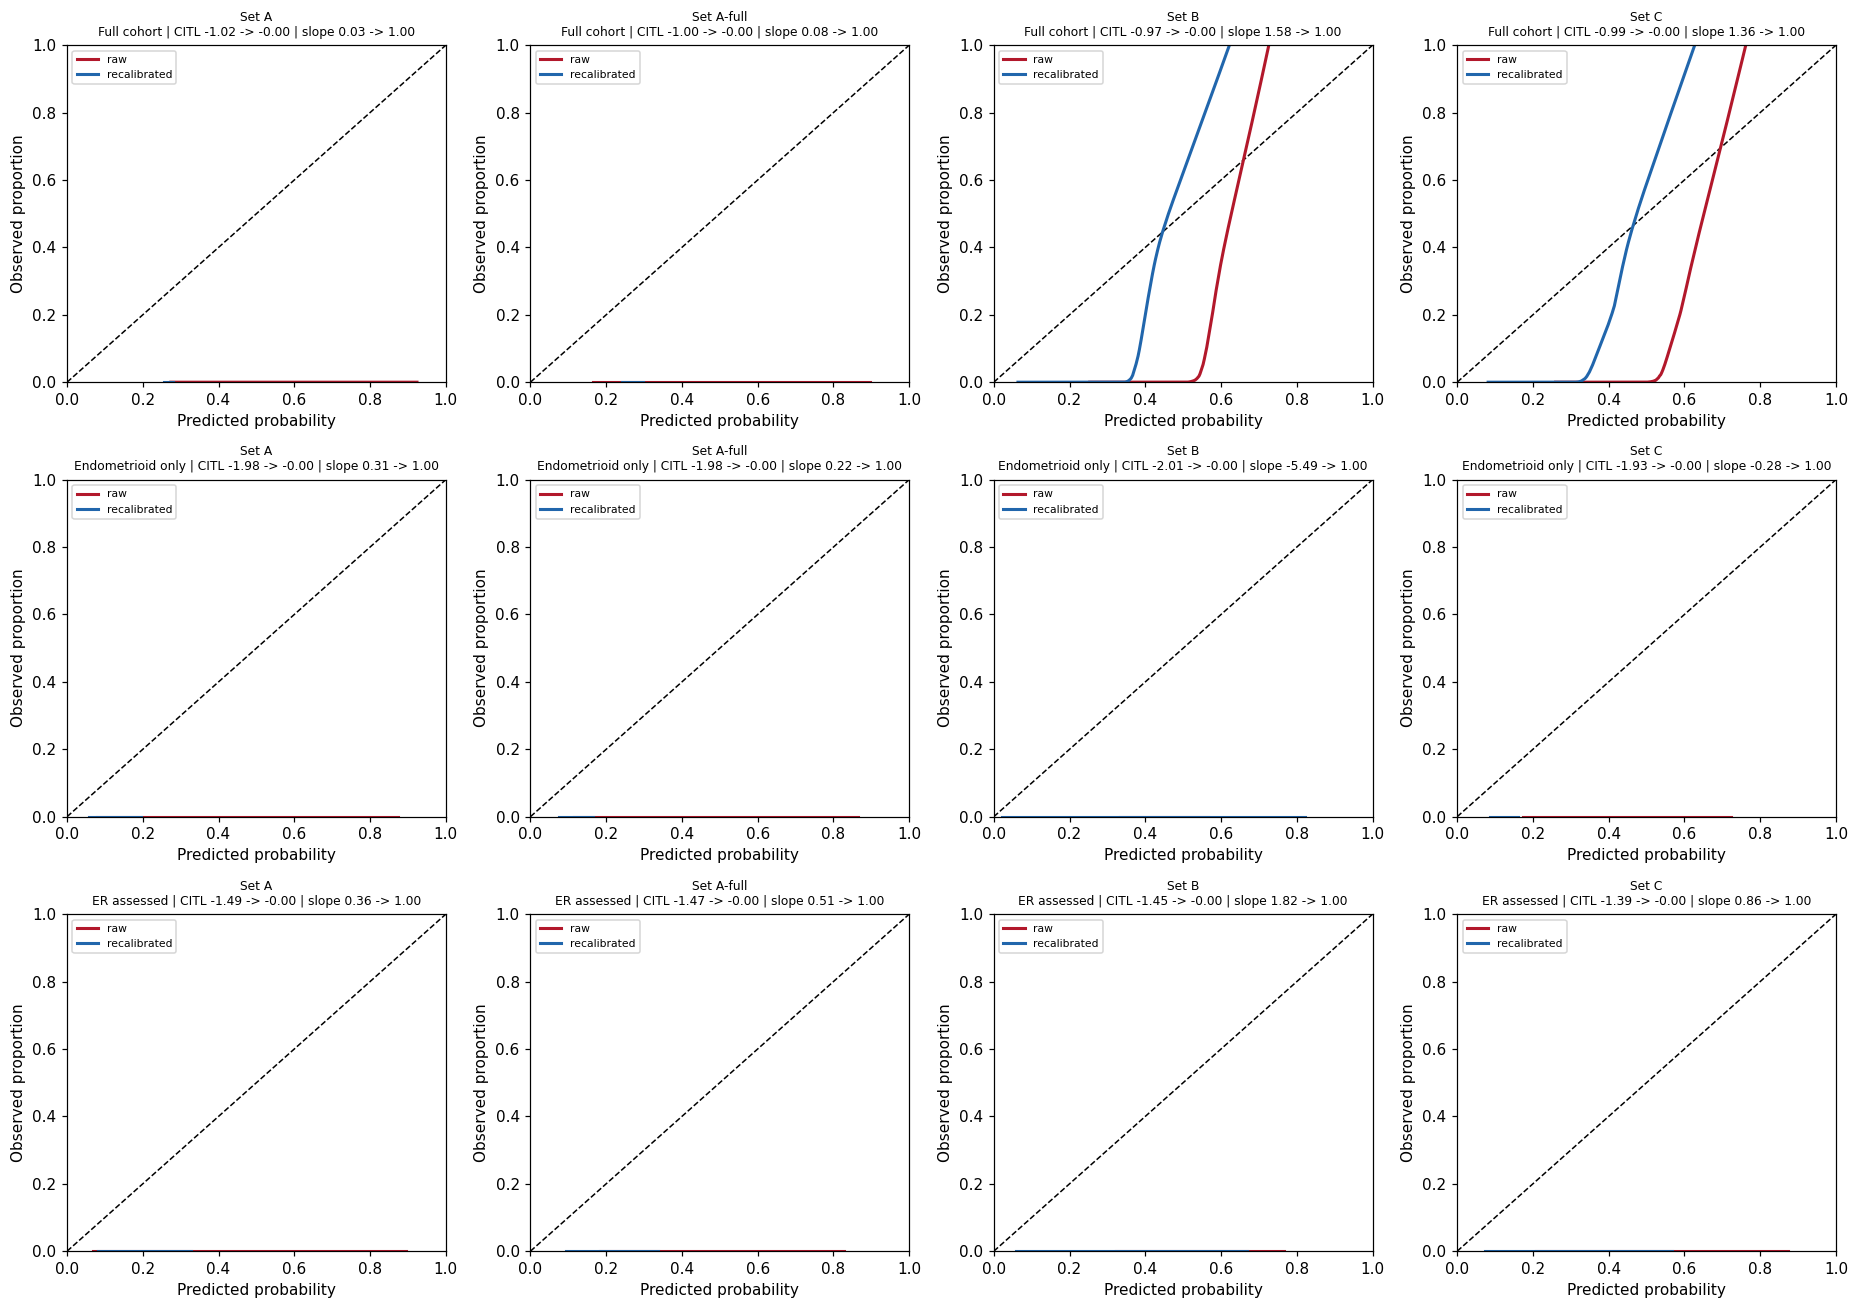

Beklenen ham CITL = log(prev/(1-prev)) = -1.034  (class_weight='balanced' etkisi)


,cohort,feature_set,raw_citl,raw_slope,recal_citl,recal_slope,raw_brier,recal_brier,brier_prevalence_only
0,Full cohort,Set A,-1.015,0.034,-0.0,1.0,0.251,0.194,0.194
1,Full cohort,Set A-full,-1.002,0.077,-0.0,1.0,0.249,0.194,0.194
2,Full cohort,Set B,-0.973,1.577,-0.0,1.0,0.225,0.177,0.195
3,Full cohort,Set C,-0.985,1.365,-0.0,1.0,0.230,0.182,0.195
4,Endometrioid only,Set A,-1.985,0.307,-0.0,1.0,0.221,0.097,0.098
5,Endometrioid only,Set A-full,-1.977,0.223,-0.0,1.0,0.224,0.098,0.098
6,Endometrioid only,Set B,-2.014,-5.494,-0.0,1.0,0.250,0.096,0.102
7,Endometrioid only,Set C,-1.931,-0.278,-0.0,1.0,0.234,0.102,0.102
8,ER assessed,Set A,-1.489,0.362,-0.0,1.0,0.234,0.144,0.145
9,ER assessed,Set A-full,-1.473,0.514,-0.0,1.0,0.233,0.144,0.145


In [ ]:

def calib_stats(yv,p,eps=1e-6):
    p=np.clip(p,eps,1-eps); lp=np.log(p/(1-p))
    slope=sm.GLM(yv,sm.add_constant(lp),family=sm.families.Binomial()).fit()
    citl =sm.GLM(yv,np.ones((len(yv),1)),family=sm.families.Binomial(),offset=lp).fit()
    return dict(citl=float(citl.params[0]), slope=float(slope.params[1]))

def recalibrate(yv,p,eps=1e-6):
    p=np.clip(p,eps,1-eps); lp=np.log(p/(1-p))
    m_=sm.GLM(yv,sm.add_constant(lp),family=sm.families.Binomial()).fit()
    return m_.predict(sm.add_constant(lp))

OOF_CAL={}; crows=[]
keys=[k for k in OOF if "(common)" not in k[0]]
fig,axes=plt.subplots(3,4,figsize=(17,12))
for ax,k in zip(axes.ravel(), keys):
    m,p,pred,yv=OOF[k]
    cs=calib_stats(yv,p); pc=recalibrate(yv,p); cs2=calib_stats(yv,pc)
    OOF_CAL[k]=pc
    crows.append(dict(cohort=k[0],feature_set=k[1],**{"raw_"+a:b for a,b in cs.items()},
                      **{"recal_"+a:b for a,b in cs2.items()},
                      raw_brier=brier_score_loss(yv,p), recal_brier=brier_score_loss(yv,pc),
                      brier_prevalence_only=yv.mean()*(1-yv.mean())))
    lo=lowess(yv,p,frac=0.75,return_sorted=True)
    lo2=lowess(yv,pc,frac=0.75,return_sorted=True)
    ax.plot([0,1],[0,1],"k--",lw=1)
    ax.plot(lo[:,0],lo[:,1],lw=2,color="#b2182b",label="raw")
    ax.plot(lo2[:,0],lo2[:,1],lw=2,color="#2166ac",label="recalibrated")
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title("%s\n%s | CITL %.2f -> %.2f | slope %.2f -> %.2f"
                 % (k[1],k[0],cs["citl"],cs2["citl"],cs["slope"],cs2["slope"]),fontsize=8)
    ax.set_xlabel("Predicted probability"); ax.set_ylabel("Observed proportion"); ax.legend(fontsize=7)
for ax in axes.ravel()[len(keys):]: ax.axis("off")
plt.tight_layout(); plt.savefig("fig_calibration.png",dpi=300); plt.show()
cal=pd.DataFrame(crows); cal.round(4).to_csv("table_calibration.csv",index=False)
print("Beklenen ham CITL = log(prev/(1-prev)) = %.3f  (class_weight='balanced' etkisi)" % np.log(y.mean()/(1-y.mean())))
cal.round(3)


## 8. Decision curve analysis

**Karar:** biyopside düşük veya belirsiz derece raporlanan hastada preoperatif olarak
kapsamlı evreleme (sistematik pelvik + paraaortik lenfadenektomi) yapmak veya
jinekolojik onkolojiye sevk etmek.

**Eşik gerekçesi:** eşik olasılık p'de örtük değiş-tokuş oranı p/(1−p)'dir. p=0.05'te
19, p=0.10'da 9, p=0.20'de 4, p=0.40'ta 1.5 gereksiz evreleme kabul edilmiş olur.
0.05–0.40 aralığı klinik olarak savunulabilir oranları kapsar.

Eğriler **yeniden kalibre edilmiş** olasılıklarla çizilir ve net fayda için bootstrap
belirsizlik bandı verilir.


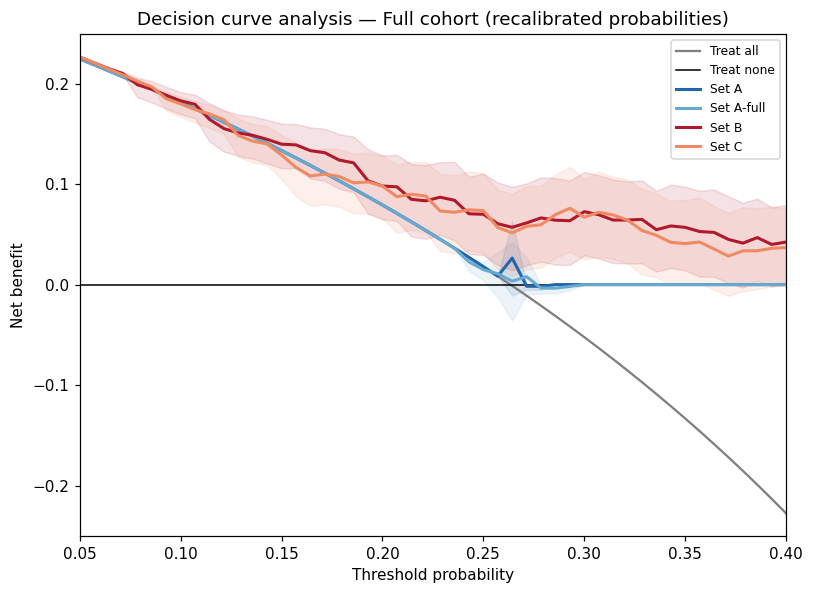

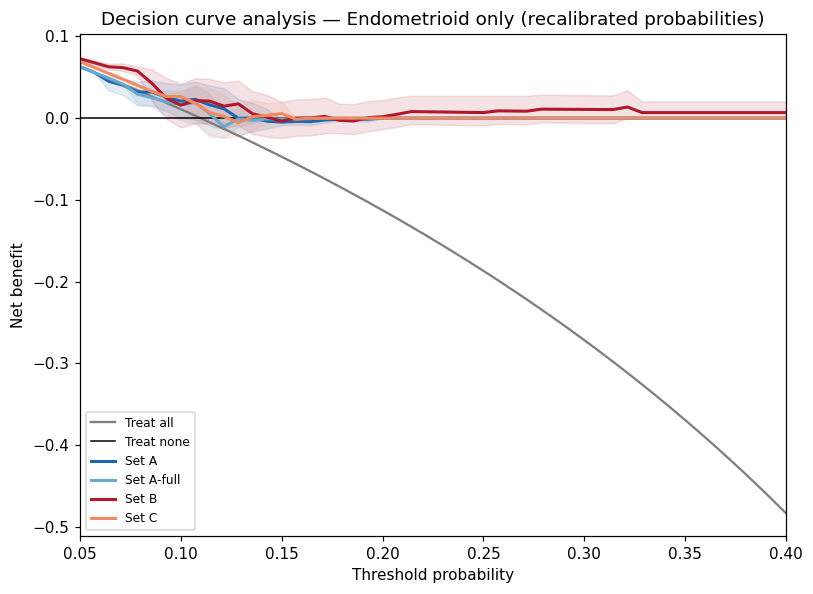

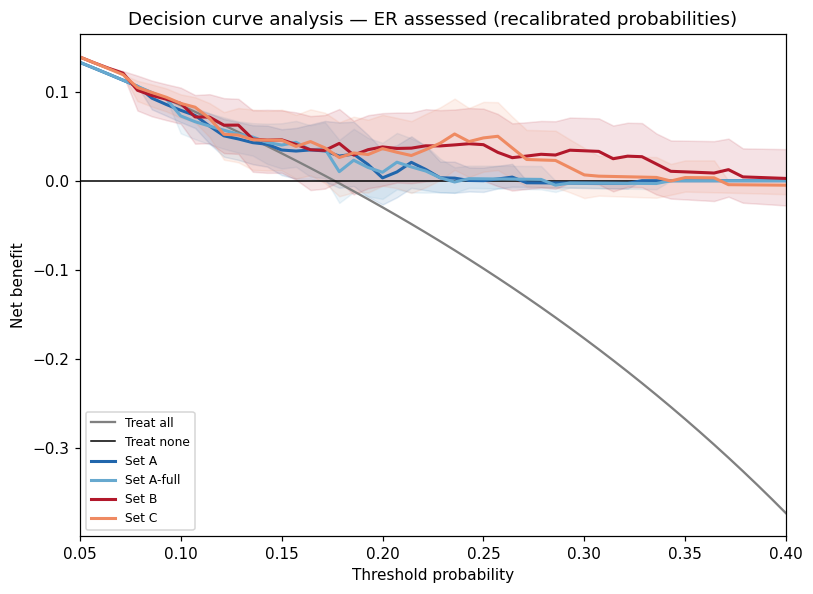

NOT: makaledeki Figur 4 HAM olasiliklarla cizilmisti ve egrilerin bir kismi
     treat-all uzerinde gorunuyordu. Bu tablo o okumayi yeniden test eder.


In [ ]:

def net_benefit(yv,p,pt):
    pred=p>=pt; n=len(yv)
    return (pred&(yv==1)).sum()/n - ((pred&(yv==0)).sum()/n)*(pt/(1-pt))

pts=np.linspace(DCA_LO,DCA_HI,50)
for cohort in COHORTS:
    ks=[k for k in OOF_CAL if k[0]==cohort]
    if not ks: continue
    plt.figure(figsize=(7.5,5.5))
    ref=OOF[ks[0]]; yref=ref[3]
    plt.plot(pts,[net_benefit(yref,np.ones(len(yref)),t) for t in pts],color="grey",lw=1.5,label="Treat all")
    plt.axhline(0,color="k",lw=1,label="Treat none")
    rows=[]
    for k,col in zip(ks,["#2166ac","#67a9cf","#b2182b","#ef8a62"]):
        m,p,pred,yv=OOF[k]; pc=OOF_CAL[k]
        nb=np.array([net_benefit(yv,pc,t) for t in pts])
        r=np.random.default_rng(SEED); ip=np.flatnonzero(yv==1); ineg=np.flatnonzero(yv==0)
        B=np.empty((min(N_BOOT,1000),len(pts)))
        for j in range(B.shape[0]):
            i=np.concatenate([r.choice(ip,ip.size,True),r.choice(ineg,ineg.size,True)])
            B[j]=[net_benefit(yv[i],pc[i],t) for t in pts]
        lo=np.percentile(B,2.5,axis=0); hi=np.percentile(B,97.5,axis=0)
        plt.plot(pts,nb,lw=2,color=col,label=k[1]); plt.fill_between(pts,lo,hi,color=col,alpha=0.12)
        rows.append(dict(cohort=cohort,feature_set=k[1],max_nb=nb.max(),pt_at_max=pts[nb.argmax()],
                         nb_010=net_benefit(yv,pc,0.10),nb_020=net_benefit(yv,pc,0.20),
                         nb_010_lo=lo[np.argmin(abs(pts-0.10))],nb_010_hi=hi[np.argmin(abs(pts-0.10))]))
    plt.xlabel("Threshold probability"); plt.ylabel("Net benefit"); plt.xlim(DCA_LO,DCA_HI)
    plt.title("Decision curve analysis — %s (recalibrated probabilities)"%cohort); plt.legend(fontsize=8)
    plt.tight_layout(); plt.savefig("fig_dca_%s.png"%cohort.replace(" ","_"),dpi=300); plt.show()
    pd.DataFrame(rows).round(4).to_csv("table_dca_%s.csv"%cohort.replace(" ","_"),index=False)
print("NOT: egriler YENIDEN KALIBRE EDILMIS olasiliklarla cizilir; DCA mutlak")
print("     olasilik olceginde tanimli oldugu icin bu zorunludur.")


## 9. İnkremental değer

Eşleşmiş bootstrap ΔAUC + DeLong + ΔBrier + ΔAUC-PR. AUC-PR kombine modelde
artabileceği için dört ölçek birlikte raporlanıyor.


In [ ]:

def auc_fast(yv,s):
    yv=np.asarray(yv,np.int8); s=np.asarray(s,float)
    n1=int(yv.sum()); n0=yv.size-n1; r=stats.rankdata(s)
    return (r[yv==1].sum()-n1*(n1+1)/2)/(n1*n0)
def delong_paired(yv,a,b):
    x1,z1=a[yv==1],a[yv==0]; x2,z2=b[yv==1],b[yv==0]; m_,n_=len(x1),len(z1)
    v10=lambda x,z: np.array([np.mean((z<xi)+0.5*(z==xi)) for xi in x])
    v01=lambda x,z: np.array([np.mean((x>zj)+0.5*(x==zj)) for zj in z])
    S10=np.cov(np.vstack([v10(x1,z1),v10(x2,z2)])); S01=np.cov(np.vstack([v01(x1,z1),v01(x2,z2)]))
    S=S10/m_+S01/n_; d=auc_fast(yv,a)-auc_fast(yv,b); var=S[0,0]+S[1,1]-2*S[0,1]
    zst=d/np.sqrt(var) if var>0 else np.nan
    return d, np.sqrt(var), 2*(1-stats.norm.cdf(abs(zst)))

rows=[]
for cohort in COHORTS:
    kB=(cohort+" (common)","Set B"); kC=(cohort+" (common)","Set C")
    if kB not in OOF or kC not in OOF: continue
    _,pB,_,yv=OOF[kB]; _,pC,_,_=OOF[kC]
    d=auc_fast(yv,pC)-auc_fast(yv,pB)
    r=np.random.default_rng(SEED); ip=np.flatnonzero(yv==1); ineg=np.flatnonzero(yv==0)
    bs=np.empty(N_BOOT)
    for j in range(N_BOOT):
        i=np.concatenate([r.choice(ip,ip.size,True),r.choice(ineg,ineg.size,True)])
        bs[j]=auc_fast(yv[i],pC[i])-auc_fast(yv[i],pB[i])
    dd,se,pdl=delong_paired(yv,pC,pB)
    rows.append(dict(cohort=cohort,n=len(yv),events=int(yv.sum()),
        dAUC=d, ci_lo=np.percentile(bs,2.5), ci_hi=np.percentile(bs,97.5),
        one_sided_ub=np.percentile(bs,95), p_two_sided=2*min((bs<=0).mean(),(bs>=0).mean()),
        delong_p=pdl, dBrier=brier_score_loss(yv,pC)-brier_score_loss(yv,pB),
        dAUCPR=average_precision_score(yv,pC)-average_precision_score(yv,pB)))
    print("%-19s dAUC %+.4f (%.4f/%.4f) | 1-sided ub %+.4f (margin +%.2f) | two-sided p %.3f | DeLong p %.3f | dBrier %+.4f | dAUC-PR %+.4f"
          % (cohort,d,rows[-1]["ci_lo"],rows[-1]["ci_hi"],rows[-1]["one_sided_ub"],
             DELTA_INC,rows[-1]["p_two_sided"],pdl,rows[-1]["dBrier"],rows[-1]["dAUCPR"]))
pd.DataFrame(rows).round(4).to_csv("table4_incremental.csv",index=False)


Full cohort         dAUC -0.0246 (-0.0623/0.0124) | 1-sided ub +0.0070 (margin +0.05) | two-sided p 0.212 | DeLong p 0.190 | dBrier +0.0054 | dAUC-PR -0.0219
Endometrioid only   dAUC +0.0738 (-0.0973/0.2430) | 1-sided ub +0.2145 (margin +0.05) | two-sided p 0.405 | DeLong p 0.401 | dBrier -0.0162 | dAUC-PR +0.0143
ER assessed         dAUC -0.0039 (-0.1034/0.0918) | 1-sided ub +0.0772 (margin +0.05) | two-sided p 0.942 | DeLong p 0.939 | dBrier -0.0084 | dAUC-PR -0.0438

YORUM: GA sifiri iceriyorsa 'inflamatuar degiskenler performansi dusuruyor' DENEMEZ.


## 10. Non-superiority testi

**Terminoloji:** bu bir equivalence testi değildir. H₀: AUC ≥ 0.70'e karşı tek yönlü
bir non-superiority testidir. Marj 0.70 **post hoc** seçilmiştir ve analiz
**exploratory** olarak raporlanmalıdır.


In [ ]:

def nonsup(yv,s,delta=DELTA_AUC,n=N_BOOT,seed=SEED,directed=True):
    yv=np.asarray(yv,np.int8); s=np.asarray(s,float)
    if directed and auc_fast(yv,s)<0.5: s=-s      # yon TAM VERIDE bir kez sabitlenir
    r=np.random.default_rng(seed); ip=np.flatnonzero(yv==1); ineg=np.flatnonzero(yv==0)
    b=np.array([auc_fast(yv[i],s[i]) for i in
        (np.concatenate([r.choice(ip,ip.size,True),r.choice(ineg,ineg.size,True)]) for _ in range(n))])
    return dict(auc=auc_fast(yv,s),lo=np.percentile(b,2.5),hi=np.percentile(b,97.5),
                ub=np.percentile(b,100*(1-ALPHA)))

rows=[]; rejects=[]
for v in ["NLR","dNLR","PLR","MLR","LMR","SII","SIRI","PIV","ELR"]:
    ok=df[v].notna().values; r=nonsup(y[ok],df.loc[ok,v].values)
    rej=r["ub"]<DELTA_AUC; rejects.append(rej)
    rows.append(dict(item=v,n=int(ok.sum()),**r,reject_H0=rej))
    print("%-6s n=%3d AUC %.3f (%.3f-%.3f) ub %.3f  %s"%(v,ok.sum(),r["auc"],r["lo"],r["hi"],r["ub"],"REJECT" if rej else "not rejected"))
for k in [("Full cohort","Set A"),("Full cohort","Set A-full")]:
    if k in OOF:
        _,p,_,yv=OOF[k]; r=nonsup(yv,p,directed=False); rej=r["ub"]<DELTA_AUC; rejects.append(rej)
        rows.append(dict(item=k[1],n=len(yv),**r,reject_H0=rej))
        print("%-6s n=%3d AUC %.3f (%.3f-%.3f) ub %.3f  %s"%(k[1],len(yv),r["auc"],r["lo"],r["hi"],r["ub"],"REJECT" if rej else "not rejected"))
print("\nIUT: %s" % ("H0 REDDEDILIR — ailedeki hicbir bilesen marja ulasmiyor" if all(rejects)
                      else "H0 REDDEDILEMEZ — en az bir bilesen marji iceriyor"))
pd.DataFrame(rows).round(4).to_csv("table_nonsuperiority.csv",index=False)


NLR    n=225 AUC 0.505 (0.418-0.590) ub 0.577  REJECT
dNLR   n=225 AUC 0.514 (0.427-0.598) ub 0.584  REJECT
PLR    n=225 AUC 0.533 (0.446-0.624) ub 0.609  REJECT
MLR    n=225 AUC 0.537 (0.454-0.625) ub 0.611  REJECT
LMR    n=224 AUC 0.535 (0.449-0.619) ub 0.606  REJECT
SII    n=225 AUC 0.500 (0.411-0.591) ub 0.577  REJECT
SIRI   n=225 AUC 0.502 (0.418-0.590) ub 0.575  REJECT
PIV    n=225 AUC 0.514 (0.427-0.603) ub 0.590  REJECT
ELR    n=225 AUC 0.626 (0.543-0.705) ub 0.694  REJECT
Set A  n=224 AUC 0.533 (0.443-0.621) ub 0.607  REJECT
Set A-full n=224 AUC 0.520 (0.432-0.609) ub 0.594  REJECT

IUT: H0 REDDEDILIR — ailedeki hicbir bilesen marja ulasmiyor


## 11. Permütasyon null'u ve güç analizi

Makaledeki null (95. persentil 0.578–0.622) **dokuz algoritmanın maksimumu** tasarımı
içindi; tek ön-tanımlı model için yeniden hesaplanmalıdır.

"440 events" ifadesi de burada Hanley–McNeil ile yeniden türetilir.


In [ ]:

def perm_null(cols,mask,n_perm=N_PERM,seed=SEED):
    X=df.loc[mask,cols].values; yv=y[mask]; r=np.random.default_rng(seed); out=[]
    for k in range(n_perm):
        yp=r.permutation(yv); p,_,_=nested_cv(X,yp,n_repeats=1,seed=seed+k)
        out.append(roc_auc_score(yp,p))
    return np.array(out)

rows=[]
for s in ["Set A","Set B"]:
    m=mask_of(SET[s]); nl=perm_null(SET[s],m)
    obs=float(tab3[(tab3.cohort=="Full cohort")&(tab3.feature_set==s)].auc.iloc[0])
    rows.append(dict(feature_set=s,n_perm=len(nl),null_mean=nl.mean(),null_p95=np.percentile(nl,95),
                     observed=obs,p_perm=(np.sum(nl>=obs)+1)/(len(nl)+1)))
    print("%-6s null mean %.3f | 95th pct %.3f | observed %.3f | perm p %.3f"
          % (s,nl.mean(),np.percentile(nl,95),obs,rows[-1]["p_perm"]))
pd.DataFrame(rows).round(4).to_csv("table_permutation_null.csv",index=False)

def hm_var(A,n1,n0):
    Q1=A/(2-A); Q2=2*A*A/(1+A)
    return (A*(1-A)+(n1-1)*(Q1-A*A)+(n0-1)*(Q2-A*A))/(n1*n0)
def n_events(A1,A0=0.5,power=0.80,alpha=0.05,k=None,two_sided=True):
    za=norm.ppf(1-alpha/(2 if two_sided else 1)); zb=norm.ppf(power)
    for n1 in range(5,20001):
        n0=int(round(k*n1))
        if (A1-A0) >= za*np.sqrt(hm_var(A0,n1,n0))+zb*np.sqrt(hm_var(A1,n1,n0)): return n1,n0
    return None,None
ratio=(1-y.mean())/y.mean()
print("\n=== SAMPLE SIZE CHECK ===")
for A,k,lab,ts in [(0.58,ratio,"cohort ratio, two-sided",True),(0.58,1.0,"balanced 1:1, two-sided",True),
                   (0.58,ratio,"cohort ratio, one-sided",False)]:
    n1,n0=n_events(A,k=k,two_sided=ts)
    print("  AUC %.2f vs 0.50, 80%% power, %-26s -> events %s, total %s"%(A,lab,n1,(n1+n0) if n1 else None))


Set A  null mean 0.499 | 95th pct 0.586 | observed 0.533 | perm p 0.254
Set B  null mean 0.495 | 95th pct 0.587 | observed 0.687 | perm p 0.005

=== SAMPLE SIZE CHECK (paper says '440 events') ===
  AUC 0.58 vs 0.50, 80% power, cohort ratio, two-sided    -> events 140, total 534
  AUC 0.58 vs 0.50, 80% power, balanced 1:1, two-sided    -> events 203, total 406
  AUC 0.58 vs 0.50, 80% power, cohort ratio, one-sided    -> events 111, total 423


## 12. ER/PR kodlamasının belgelenmesi — modelleme DEĞİL

**Yazar teyidi:** ER ve PR preoperatif biyopside çalışılmıyor, **ve** bakılan her hastada
ER pozitif. SPSS değer etiketleri bunu doğruluyor: 1='10-20' … 9='90-100', 10='only
positive'. **Negatif kategorisi yok.**

Sonuç: `0` kodu "ER negatif" değil, **"bakılmamış"** demektir. Makalenin Tablo 1'inde
"ER status Negative (0): 14 / 23, p<0.001" olarak raporlanan satır, derece ile reseptör
durumu arasındaki bir ilişki değil, **derece ile reseptörün istenip istenmediği**
arasındaki bir ilişkidir.

Bu bölüm hiçbir model kurmaz; sorunu belgeler ve Tablo 1 için doğru sayıları üretir.


In [ ]:

er=df["östrojen"]; pr=df["progesteron"]
rows=[]
for nm,v in [("ER",er),("PR",pr)]:
    st=pd.Series(np.where(v.isna(),"no record",np.where(v==0,"code 0 = NOT ASSESSED","assessed, positive")),
                 index=df.index)
    ct=pd.crosstab(st, df.y); ct.columns=["G1-G2","G3"]; ct["G3 %"]=(100*ct["G3"]/ct.sum(axis=1)).round(1)
    ce=pd.crosstab(st, df.endometrioid); ce.columns=["non-endometrioid","endometrioid"]
    ce["endometrioid %"]=(100*ce["endometrioid"]/ce.sum(axis=1)).round(1)
    print("=== %s ==="%nm); print(ct.to_string()); print(ce[["endometrioid %"]].to_string()); print()
    out=ct.join(ce[["endometrioid %"]]).reset_index().rename(columns={"index":"category"})
    out.insert(0,"marker",nm); rows.append(out)
tab=pd.concat(rows); tab.to_csv("tableS7_ERPR_assessment.csv",index=False)

print("YORUM")
print(" - Bakilan hastalarin tamami ER/PR pozitif; kohortta reseptor NEGATIFLIGI YOK.")
print(" - '0' kodlu grupta G3 orani cok daha yuksek ve non-endometrioid orani cok daha yuksek.")
print(" - Yani reseptor istenmemesi, tumorun zaten acikca yuksek dereceli/non-endometrioid")
print("   olmasiyla iliskili. Modele konuldugunda bu degisken bir EKSIKLIK GOSTERGESI olarak")
print("   ogreniliyor ve dolayli olarak histolojik alt tipi -> tanim geregi G3'u kodluyor.")
print()


=== ER ===
                       G1-G2  G3  G3 %
row_0                                 
assessed, positive       131  28  17.6
code 0 = NOT ASSESSED     14  23  62.2
no record                 21   8  27.6
                       endometrioid %
row_0                                
assessed, positive               87.4
code 0 = NOT ASSESSED            51.4
no record                        86.2

=== PR ===
                       G1-G2  G3  G3 %
row_0                                 
assessed, positive       128  27  17.4
code 0 = NOT ASSESSED     17  24  58.5
no record                 21   8  27.6
                       endometrioid %
row_0                                
assessed, positive               88.4
code 0 = NOT ASSESSED            51.2
no record                        86.2

YORUM
 - Bakilan hastalarin tamami ER/PR pozitif; kohortta reseptor NEGATIFLIGI YOK.
 - '0' kodlu grupta G3 orani cok daha yuksek ve non-endometrioid orani cok daha yuksek.
 - Yani reseptor istenmemesi, tum

## 13. MICE duyarlılık analizi

Imputation **her eğitim fold'unun içinde** yapılır; dış test fold'u imputation modeline
katkıda bulunmaz.


In [ ]:

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

def nested_cv_mice(cols, mask0, n_repeats=max(3,N_REPEATS//4), seed=SEED):
    m = mask0 & (~df.GRADE.isna().values)
    X = df.loc[m, cols].values; yv = y[m]
    psum=np.zeros(len(yv))
    for rep in range(n_repeats):
        for tr,te in StratifiedKFold(5,shuffle=True,random_state=seed+rep).split(X,yv):
            pipe=Pipeline([("imp",IterativeImputer(max_iter=20,random_state=seed+rep,sample_posterior=True)),
                           ("sc",StandardScaler()),
                           ("clf",LogisticRegression(penalty="elasticnet",solver="saga",max_iter=20000,
                                                     class_weight="balanced",random_state=seed))])
            g=GridSearchCV(pipe,GRID,scoring="roc_auc",cv=StratifiedKFold(5,shuffle=True,random_state=seed+rep),
                           n_jobs=-1,error_score=0.5)
            g.fit(X[tr],yv[tr]); psum[te]+=g.best_estimator_.predict_proba(X[te])[:,1]
    return psum/n_repeats, yv

rows=[]
for cohort in COHORTS:
    base = COHORTS[cohort]
    for s in ["Set B","Set C"]:
        p,yv = nested_cv_mice(SET[s], base)
        if yv.sum()<8: continue
        lo,hi=boot_auc_ci(yv,p)
        rows.append(dict(cohort=cohort,feature_set=s,method="MICE (all patients)",
                         n=len(yv),events=int(yv.sum()),auc=roc_auc_score(yv,p),ci_lo=lo,ci_hi=hi,
                         brier=brier_score_loss(yv,p)))
        print("%-19s %-6s MICE n=%3d ev=%2d AUC %.3f (%.3f-%.3f)"%(cohort,s,len(yv),yv.sum(),roc_auc_score(yv,p),lo,hi))
pd.DataFrame(rows).round(4).to_csv("table_mice_sensitivity.csv",index=False)


Full cohort         Set B  MICE n=225 ev=59 AUC 0.693 (0.608-0.774)
Full cohort         Set C  MICE n=225 ev=59 AUC 0.691 (0.606-0.773)
Endometrioid only   Set B  MICE n=183 ev=20 AUC 0.397 (0.255-0.546)
Endometrioid only   Set C  MICE n=183 ev=20 AUC 0.517 (0.388-0.647)
ER assessed         Set B  MICE n=159 ev=28 AUC 0.639 (0.498-0.771)
ER assessed         Set C  MICE n=159 ev=28 AUC 0.656 (0.523-0.782)
Complete-case sonuclariyla karsilastirin (bolum 5). Buyuk fark varsa eksiklik bilgilendiricidir.


## 14. Hiperparametre raporu ve SHAP

SHAP için kritik nokta: `shap.TreeExplainer` varsayılan olarak **log-odds** (raw)
ölçeğinde çalışır. Makalenin Figür 3 başlığı "predicted probability" diyor — yanlış.
Aşağıda ölçek açıkça yazdırılır.


  model               : Elastic-net logistic regression (prespecified primary)
  C_grid              : np.logspace(-5, 1, 20)
  l1_ratio_grid       : [0.0, 0.5, 1.0]
  n_configurations    : 60
  search              : exhaustive grid (GridSearchCV)
  refit_rule          : best
  inner_resampling    : stratified 5-fold
  outer_resampling    : stratified 5-fold
  outer_repeats       : 20
  scoring             : roc_auc
  class_imbalance     : class_weight='balanced'
  imputation          : fold-wise median (no-op in complete-case sets)
  scaling             : StandardScaler, fitted within fold
  threshold           : Youden J, selected WITHIN each training fold
  solver              : saga, max_iter=20000
  seed                : 42
  versions            : sklearn 1.6.1, scipy 1.16.3, numpy 2.1.3, statsmodels 0.14.6, shap 0.52.0

PRIMARY model standardized coefficients (C=0.1274, l1=0.0):
age              0.6117
CA125            0.2483
albumin_preop   -0.0861

EXPLORATORY tree model — mean

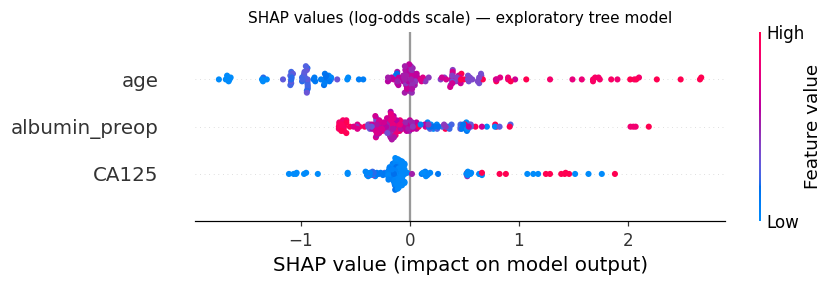


Figur basligi 'contributions to the log-odds of high-grade disease' olmali,
'predicted probability' DEGIL.


In [ ]:

import sklearn, scipy, shap
meta=dict(model="Elastic-net logistic regression (prespecified primary)",
          C_grid="np.logspace(-5, 1, 20)", l1_ratio_grid=str(GRID["clf__l1_ratio"]),
          n_configurations=len(GRID["clf__C"])*len(GRID["clf__l1_ratio"]),
          search="exhaustive grid (GridSearchCV)", refit_rule=REFIT_RULE,
          inner_resampling="stratified 5-fold", outer_resampling="stratified 5-fold",
          outer_repeats=N_REPEATS, scoring="roc_auc", class_imbalance="class_weight='balanced'",
          imputation="fold-wise median (no-op in complete-case sets)",
          scaling="StandardScaler, fitted within fold",
          threshold="Youden J, selected WITHIN each training fold",
          solver="saga, max_iter=20000", seed=SEED,
          versions="sklearn %s, scipy %s, numpy %s, statsmodels %s, shap %s"
                   %(sklearn.__version__,scipy.__version__,np.__version__,sm.__version__,shap.__version__))
for k,v in meta.items(): print("  %-20s: %s"%(k,v))
json.dump(meta,open("tableS6_hyperparameters.json","w"),indent=2)

# --- birincil (lineer) model katsayilari ---
m=mask_of(SET["Set B"]); Xb=df.loc[m,SET["Set B"]].values; yb=y[m]
g=GridSearchCV(clone(estimator()),GRID,scoring="roc_auc",cv=StratifiedKFold(5,shuffle=True,random_state=SEED),
               refit=_refit(REFIT_RULE),n_jobs=-1,error_score=0.5).fit(Xb,yb)
coef=pd.Series(g.best_estimator_.named_steps["clf"].coef_[0],index=SET["Set B"])
print("\nPRIMARY model standardized coefficients (C=%.4g, l1=%.1f):"
      % (g.best_params_["clf__C"],g.best_params_["clf__l1_ratio"]))
print(coef.round(4).to_string()); coef.rename("coef").to_csv("table_primary_coefficients.csv")

# --- kesifci agac modeli SHAP (LOG-ODDS olceginde) ---
from sklearn.ensemble import GradientBoostingClassifier
gb=GradientBoostingClassifier(random_state=SEED,max_depth=2,n_estimators=200,learning_rate=0.05).fit(
   SimpleImputer(strategy="median").fit_transform(Xb),yb)
sv=shap.TreeExplainer(gb).shap_values(SimpleImputer(strategy="median").fit_transform(Xb))
msh=pd.Series(np.abs(sv).mean(0),index=SET["Set B"]).sort_values(ascending=False)
print("\nEXPLORATORY tree model — mean |SHAP| (scale: LOG-ODDS, model_output='raw'):")
print(msh.round(4).to_string()); msh.rename("mean_abs_shap_logodds").to_csv("table_shap_exploratory.csv")
shap.summary_plot(sv,features=Xb,feature_names=SET["Set B"],show=False)
plt.title("SHAP values (log-odds scale) — exploratory tree model",fontsize=10)
plt.tight_layout(); plt.savefig("fig_shap.png",dpi=300); plt.show()
print("\nFigur basligi 'contributions to the log-odds of high-grade disease' olmali,")
print("'predicted probability' DEGIL.")


## 15. Çıktıları indir


In [ ]:

import glob, zipfile
outs=sorted(glob.glob("table*.csv")+glob.glob("table*.json")+glob.glob("fig_*.png")+glob.glob("*.npz"))
with zipfile.ZipFile("revision_outputs_v2.zip","w") as z:
    for f in outs: z.write(f)
print("Packaged %d files:"%len(outs)); [print("  ",f) for f in outs]
try:
    from google.colab import files; files.download("revision_outputs_v2.zip")
except Exception as e: print("indirme atlandi:",e)


Packaged 26 files:
   fig_calibration.png
   fig_dca_ER_assessed.png
   fig_dca_Endometrioid_only.png
   fig_dca_Full_cohort.png
   fig_shap.png
   oof_primary.npz
   table3_primary.csv
   table4_incremental.csv
   tableS2_missingness.csv
   tableS2b_missing_pattern.csv
   tableS2c_included_vs_excluded.csv
   tableS3_common_cohort.csv
   tableS4_foldwise_vif.csv
   tableS5_subtype_by_grade.csv
   tableS6_hyperparameters.json
   tableS7_ERPR_assessment.csv
   table_calibration.csv
   table_dca_ER_assessed.csv
   table_dca_Endometrioid_only.csv
   table_dca_Full_cohort.csv
   table_mice_sensitivity.csv
   table_nonsuperiority.csv
   table_permutation_null.csv
   table_primary_coefficients.csv
   table_refit_rule.csv
   table_shap_exploratory.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>